In [ ]:

# ================================================================
# DATA LOADING: Live NSE Options Chain via nsepython
# Falls back to local CSV if nsepython / network unavailable
# ================================================================
import pandas as pd
import numpy as np
import glob

def fetch_nse_options(symbol='NIFTY'):
    """
    Fetch live NSE options chain for the nearest expiry.
    Returns (df, True) on success, (None, False) on failure.
    df has standard column names: STRIKE, CE_IV, PE_IV, CE_LTP, PE_LTP, etc.
    """
    try:
        from nsepython import nse_optionchain_scrapper
        print(f"Fetching live NSE {symbol} options chain...")
        raw = nse_optionchain_scrapper(symbol)
        records = raw['records']['data']

        rows = []
        for rec in records:
            strike = rec.get('strikePrice')
            ce = rec.get('CE', {})
            pe = rec.get('PE', {})
            rows.append({
                'CE_OI':        ce.get('openInterest', np.nan),
                'CE_CHNG_OI':   ce.get('changeinOpenInterest', np.nan),
                'CE_VOLUME':    ce.get('totalTradedVolume', np.nan),
                'CE_IV':        ce.get('impliedVolatility', np.nan),
                'CE_LTP':       ce.get('lastPrice', np.nan),
                'CE_CHNG':      ce.get('change', np.nan),
                'CE_BID_QTY':   ce.get('bidQty', np.nan),
                'CE_BID':       ce.get('bidprice', np.nan),
                'CE_ASK':       ce.get('askPrice', np.nan),
                'CE_ASK_QTY':   ce.get('askQty', np.nan),
                'STRIKE':       strike,
                'PE_BID_QTY':   pe.get('bidQty', np.nan),
                'PE_BID':       pe.get('bidprice', np.nan),
                'PE_ASK':       pe.get('askPrice', np.nan),
                'PE_ASK_QTY':   pe.get('askQty', np.nan),
                'PE_CHNG':      pe.get('change', np.nan),
                'PE_LTP':       pe.get('lastPrice', np.nan),
                'PE_IV':        pe.get('impliedVolatility', np.nan),
                'PE_VOLUME':    pe.get('totalTradedVolume', np.nan),
                'PE_CHNG_OI':   pe.get('changeinOpenInterest', np.nan),
                'PE_OI':        pe.get('openInterest', np.nan),
            })

        df = pd.DataFrame(rows)
        print(f"  Live data: {len(df)} strikes fetched successfully.")
        return df, True

    except Exception as e:
        print(f"nsepython unavailable ({type(e).__name__}: {e})")
        return None, False


def load_local_csv():
    """Load the most recent option-chain CSV from the current directory."""
    csv_files = sorted(glob.glob('option-chain*.csv'))
    if not csv_files:
        raise FileNotFoundError("No option-chain CSV found. Run nsepython or download from NSE.")
    path = csv_files[-1]
    print(f"Loading local CSV: {path}")

    raw = pd.read_csv(path, skiprows=1)
    raw.columns = raw.columns.str.strip()
    raw = raw.drop(columns=[c for c in raw.columns if c.startswith('Unnamed')], errors='ignore')
    raw.columns = [
        'CE_OI','CE_CHNG_OI','CE_VOLUME','CE_IV','CE_LTP','CE_CHNG',
        'CE_BID_QTY','CE_BID','CE_ASK','CE_ASK_QTY',
        'STRIKE',
        'PE_BID_QTY','PE_BID','PE_ASK','PE_ASK_QTY',
        'PE_CHNG','PE_LTP','PE_IV','PE_VOLUME','PE_CHNG_OI','PE_OI'
    ]
    return raw


# --- Attempt live fetch first ---
df, LIVE_DATA = fetch_nse_options('NIFTY')

if not LIVE_DATA:
    print("Falling back to local CSV...")
    df = load_local_csv()

print(f"\nData source : {'Live NSE (nsepython)' if LIVE_DATA else 'Local CSV'}")
print(f"Shape       : {df.shape}")
df.head()


In [45]:
!pip install yfinance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Conceptual Summary:
This sets up the numerical + optimization environment needed for modelling.

In derivatives, you rarely get closed-form answers which implies you fit models numerically.

minimize is critical because calibration = reverse-engineering market expectations.

In [ ]:

# Data already loaded in cell 0 (live or CSV). Verify shape and columns.
print("Columns:", df.columns.tolist())
print("Shape  :", df.shape)
df.head()


In [ ]:

# Normalize numeric types for both live and CSV paths
# For CSV path, CE_IV/PE_IV may be strings with '-' for missing values

for col in ['STRIKE', 'CE_IV', 'PE_IV', 'CE_LTP', 'PE_LTP']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '').str.strip().replace('-', np.nan),
            errors='coerce'
        )

# For live nsepython data, IV is already a percentage (e.g. 15.3 means 15.3%)
# For CSV data, IV column may also already be in percentage form
# We convert to decimal (divide by 100) only if values look like percentages
for col in ['CE_IV', 'PE_IV']:
    if df[col].dropna().median() > 1.0:   # values like 15, 20 => percentage
        df[col] = df[col] / 100.0

print("Sample after normalizing:")
print(df[['STRIKE','CE_IV','PE_IV','CE_LTP','PE_LTP']].dropna(subset=['CE_IV']).head(8))


In [ ]:

# Build combined CE + PE IV dataframe for smile analysis
df_ce = df[['STRIKE', 'CE_IV']].rename(columns={'CE_IV': 'IV'})
df_pe = df[['STRIKE', 'PE_IV']].rename(columns={'PE_IV': 'IV'})

df_all = pd.concat([df_ce, df_pe], ignore_index=True)
df_all = df_all.dropna()
df_all = df_all[df_all['IV'] > 0]

print(f"Combined IV data points: {len(df_all)}")
print(df_all.describe())


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['STRIKE'], df['CE_IV'], label='Call IV', alpha=0.5, color='blue', s=15)
axes[0].scatter(df['STRIKE'], df['PE_IV'], label='Put IV',  alpha=0.5, color='red',  s=15)
axes[0].set_title("Call vs Put IV by Strike")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Implied Volatility (decimal)")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(df_all['STRIKE'], df_all['IV'], color='blue', alpha=0.6, s=15)
axes[1].set_title("NIFTY Volatility Smile (Combined CE + PE)")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Implied Volatility (decimal)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("-> Put IV > Call IV for lower strikes = market pricing downside crash risk")
print("-> Typical volatility smile / skew pattern for equity indices")


In [ ]:

# Remove old cell-8 logic (IV conversion) - already handled in cell-4/5 above
# This cell now just confirms df_all readiness
print(f"df_all ready: {len(df_all)} rows | IV range: [{df_all['IV'].min():.4f}, {df_all['IV'].max():.4f}]")
df_all.head()


In [ ]:

import yfinance as yf
from datetime import date

# =========================
# GET SPOT PRICE (NIFTY 50)
# =========================
spot_data = yf.download('^NSEI', period='5d', progress=False)
if isinstance(spot_data.columns, pd.MultiIndex):
    spot_data.columns = spot_data.columns.droplevel(1)

F = float(spot_data['Close'].iloc[-1])

# Time to expiry: compute from today to nearest monthly expiry (last Thursday)
# For simplicity, use a fixed T if near-expiry data is loaded
today = date.today()
# Try to infer expiry from CSV filename, else assume 5 calendar days
T = 5 / 365   # default: ~1 week

print(f"Spot (F)          : {F:,.2f}")
print(f"Time to expiry (T): {T:.6f} years  ({T*365:.1f} calendar days)")
print(f"Data points       : {len(df_all)}")


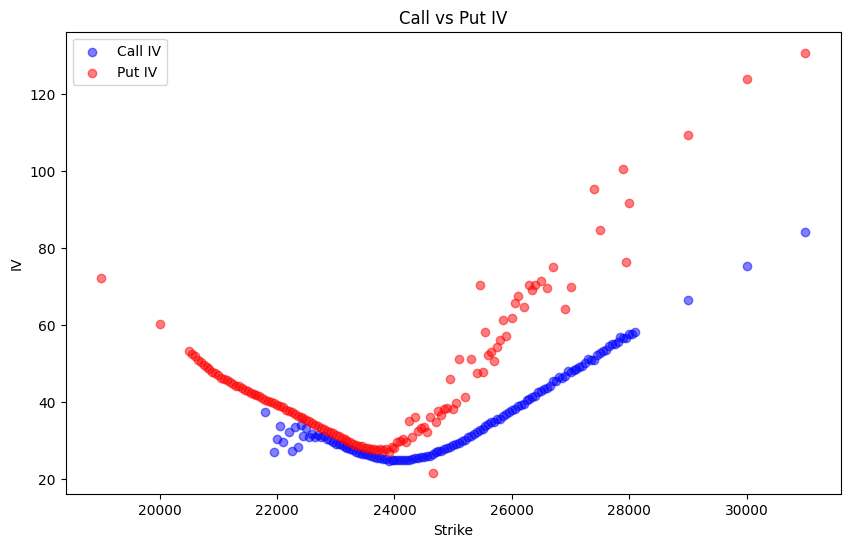

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df['STRIKE'], df['CE_IV'], label='Call IV', alpha=0.5, color='blue')
plt.scatter(df['STRIKE'], df['PE_IV'], label='Put IV', alpha=0.5, color='red')

plt.legend()
plt.title("Call vs Put IV")
plt.xlabel("Strike")
plt.ylabel("IV")

plt.show()

Put IV > Call IV (especially for lower strikes)

As Markets are fearing more crash these days due to the Iran - US Escalations

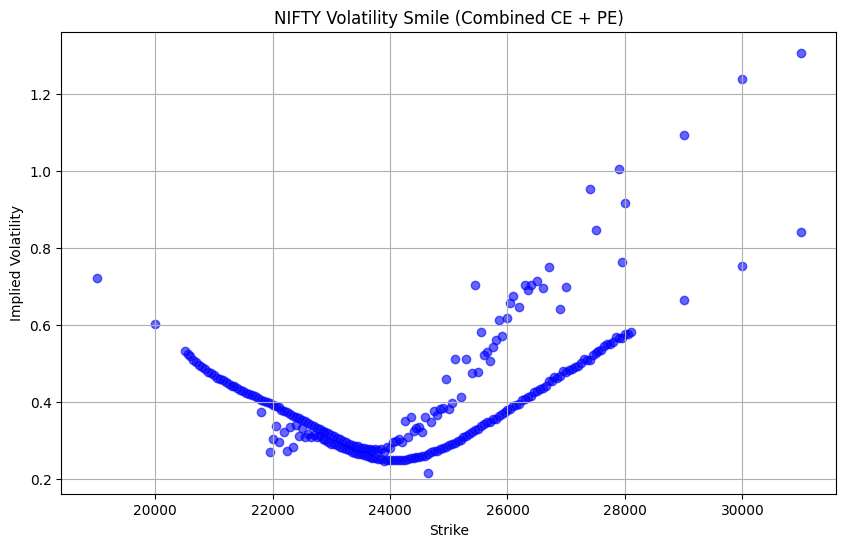

→ Each point represents market-implied volatility at a given strike.
→ Curve shape shows how risk is priced across different market scenarios.
→ Typically skewed: higher IV for lower strikes (crash risk).



In [53]:
plt.figure(figsize=(10,6))

plt.scatter(df_all['STRIKE'], df_all['IV'], color='blue', alpha=0.6)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("NIFTY Volatility Smile (Combined CE + PE)")

plt.grid(True)
plt.show()

print("→ Each point represents market-implied volatility at a given strike.")
print("→ Curve shape shows how risk is priced across different market scenarios.")
print("→ Typically skewed: higher IV for lower strikes (crash risk).\n")

In [54]:
import numpy as np
import yfinance as yf

# =========================
# GET SPOT PRICE
# =========================
spot_data = yf.download('^NSEI', start='2026-02-01', end='2026-04-01')

if isinstance(spot_data.columns, pd.MultiIndex):
    spot_data.columns = spot_data.columns.droplevel(1)

F = spot_data['Close'].iloc[-1]

# =========================
# DEFINE VARIABLES
# =========================
K = df_all['STRIKE'].values
market_vols = df_all['IV'].values

T = 5/365  # approx time to expiry

print("Spot (F):", F)
print("Number of data points:", len(K))

/tmp/ipykernel_10351/816529215.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spot_data = yf.download('^NSEI', start='2026-02-01', end='2026-04-01')
[*********************100%***********************]  1 of 1 completed

Spot (F): 23306.44921875
Number of data points: 255



A volatility surface slice using Strike Price and Time

Mathematically:

𝜎
=
𝑓
(
𝐾
,
𝑇
)
σ=f(K,T)

In [55]:
def sabr_volatility(F, K, T, alpha, beta, rho, nu):
    K = max(K, 1e-12)

    if abs(F - K) < 1e-8:
        return alpha * F**(beta - 1)

    z = nu / alpha * (F * K)**((1 - beta) / 2) * np.log(F / K)
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho)/(1 - rho))

    return (alpha / ((F*K)**((1-beta)/2))) * (z / x_z)

In [56]:
from scipy.optimize import minimize

df_all['Moneyness'] = df_all['STRIKE'] / F

# Keep only near-ATM region
df_filtered = df_all[(df_all['Moneyness'] > 0.95) & (df_all['Moneyness'] < 1.05)]

K = df_filtered['STRIKE'].values
market_vols = df_filtered['IV'].values

print("Filtered points:", len(K))

q_low = df_filtered['IV'].quantile(0.05)
q_high = df_filtered['IV'].quantile(0.95)

df_filtered = df_filtered[
    (df_filtered['IV'] > q_low) &
    (df_filtered['IV'] < q_high)
]

df_filtered = df_filtered.sort_values(by='STRIKE')

K = df_filtered['STRIKE'].values
market_vols = df_filtered['IV'].values



Filtered points: 93


In [ ]:

def objective(params):
    alpha, rho, nu = params
    beta = 0.5

    model = np.array([sabr_volatility(F, k, T, alpha, beta, rho, nu) for k in K])

    # Weight: higher near ATM
    weights = np.exp(-((K / F - 1) ** 2) / 0.01)

    error = weights * (model - market_vols) ** 2
    return np.sum(error)


# Initial parameter guess: [alpha, rho, nu]
# alpha: ~ATM vol level; rho: slight negative skew; nu: moderate vol-of-vol
initial = [np.mean(market_vols), -0.3, 0.5]

# Parameter bounds
bounds = [
    (1e-4, 2.0),    # alpha: positive, not too large
    (-0.999, 0.999),# rho:   correlation, strictly in (-1, 1)
    (1e-4, 2.0),    # nu:    vol-of-vol, positive
]

print("Objective function defined.")
print(f"Initial guess : alpha={initial[0]:.4f}, rho={initial[1]:.4f}, nu={initial[2]:.4f}")
print(f"Bounds        : {bounds}")


In [ ]:
result = minimize(
    objective,
    initial,
    bounds=bounds,
    method='L-BFGS-B',
    options={'maxiter': 500}
)

# Convergence check
if not result.success:
    print(f"WARNING: Optimization did not converge. Message: {result.message}")
else:
    print("Optimization converged successfully.")

alpha, rho, nu = result.x
beta = 0.5

print(f"\nCalibrated SABR Parameters:")
print(f"  alpha = {alpha:.5f}  (overall vol level)")
print(f"  beta  = {beta:.5f}  (elasticity, fixed)")
print(f"  rho   = {rho:.5f}  (skew; negative = downside fear)")
print(f"  nu    = {nu:.5f}  (vol-of-vol; higher = more smile curvature)")

# =========================
# MODEL FIT VISUALIZATION & ERROR METRICS
# =========================
K_plot = np.linspace(K.min(), K.max(), 300)
sabr_vols = np.array([sabr_volatility(F, k, T, alpha, beta, rho, nu) for k in K_plot])

# Fitted values at actual market strikes
model_fit = np.array([sabr_volatility(F, k, T, alpha, beta, rho, nu) for k in K])

# Error metrics
rmse = np.sqrt(np.mean((model_fit - market_vols)**2))
mae  = np.mean(np.abs(model_fit - market_vols))
max_err = np.max(np.abs(model_fit - market_vols))

print("=== Calibration Quality ===")
print(f"  RMSE : {rmse*100:.4f}% vol points")
print(f"  MAE  : {mae*100:.4f}% vol points")
print(f"  Max  : {max_err*100:.4f}% vol points")

# Plot: Market vs SABR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: smile fit
axes[0].scatter(K / F, market_vols * 100, color='blue', alpha=0.6, label='Market IV', s=20)
axes[0].plot(K_plot / F, sabr_vols * 100, color='red', linewidth=2, label='SABR Fit')
axes[0].set_xlabel("Moneyness (K/F)")
axes[0].set_ylabel("Implied Volatility (%)")
axes[0].set_title("SABR Calibration: Market vs Model")
axes[0].legend()
axes[0].grid(True)
axes[0].axvline(x=1.0, color='gray', linestyle=':', label='ATM')

# Right: residuals
residuals = (model_fit - market_vols) * 100
axes[1].bar(K / F, residuals, color=['red' if r > 0 else 'green' for r in residuals], alpha=0.7, width=0.002)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel("Moneyness (K/F)")
axes[1].set_ylabel("Residual (model - market, % vol)")
axes[1].set_title("Calibration Residuals by Strike")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n=== Market Interpretation ===")
print(f"  rho = {rho:.4f} → {'Negative skew: market pricing in downside crash risk' if rho < 0 else 'Positive skew: market pricing in upside risk'}")
print(f"  nu  = {nu:.4f} → {'High vol-of-vol: significant smile curvature, uncertainty about uncertainty' if nu > 1 else 'Low vol-of-vol: relatively flat smile'}")

In [ ]:

# =========================
# MODEL FIT VISUALIZATION & ERROR METRICS
# =========================
K_plot = np.linspace(K.min(), K.max(), 300)
sabr_vols = np.array([sabr_volatility(F, k, T, alpha, beta, rho, nu) for k in K_plot])

# Fitted values at actual market strikes
model_fit = np.array([sabr_volatility(F, k, T, alpha, beta, rho, nu) for k in K])

# Error metrics
rmse    = np.sqrt(np.mean((model_fit - market_vols) ** 2))
mae     = np.mean(np.abs(model_fit - market_vols))
max_err = np.max(np.abs(model_fit - market_vols))

print("=== Calibration Quality ===")
print(f"  RMSE : {rmse*100:.4f}% vol points")
print(f"  MAE  : {mae*100:.4f}% vol points")
print(f"  Max  : {max_err*100:.4f}% vol points")

# --- Plot: Market vs SABR ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: smile fit
axes[0].scatter(K / F, market_vols * 100, color='blue', alpha=0.6, label='Market IV', s=20)
axes[0].plot(K_plot / F, sabr_vols * 100, color='red', linewidth=2, label='SABR Fit')
axes[0].axvline(x=1.0, color='gray', linestyle=':', linewidth=1, label='ATM')
axes[0].set_xlabel("Moneyness (K/F)")
axes[0].set_ylabel("Implied Volatility (%)")
axes[0].set_title("SABR Calibration: Market vs Model")
axes[0].legend()
axes[0].grid(True)

# Right: residuals bar chart
residuals = (model_fit - market_vols) * 100
bar_colors = ['red' if r > 0 else 'green' for r in residuals]
axes[1].bar(K / F, residuals, color=bar_colors, alpha=0.7, width=0.002)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel("Moneyness (K/F)")
axes[1].set_ylabel("Residual (model - market, % vol)")
axes[1].set_title(f"Calibration Residuals  |  RMSE={rmse*100:.3f}%  MAE={mae*100:.3f}%")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n=== Market Interpretation ===")
print(f"  rho = {rho:.4f} => {'Negative skew: downside crash fear' if rho < 0 else 'Positive skew: upside risk priced in'}")
print(f"  nu  = {nu:.4f}  => {'High vol-of-vol: wide smile curvature' if nu > 1 else 'Low vol-of-vol: relatively flat smile'}")


In [ ]:

# ================================================================
# GREEKS CALCULATION USING SABR-CALIBRATED IMPLIED VOLATILITY
# ================================================================
# Method: compute SABR sigma at each strike, then plug into
# Black-Scholes Greeks formulae (forward-price / discounted form).
# r = approximate Indian risk-free rate (RBI repo rate ~6.5%)
# ================================================================
from scipy.stats import norm

r = 0.065   # risk-free rate

def bs_greeks(F, K, T, sigma, r, option_type='call'):
    """
    Black-Scholes Greeks using SABR-implied vol (sigma).
    Returns dict: price, delta, gamma, vega, theta, rho_greek.
    """
    if T <= 0 or sigma <= 0 or K <= 0:
        return {g: np.nan for g in ['price','delta','gamma','vega','theta','rho_greek']}

    sqrt_T = np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    disc = np.exp(-r * T)

    if option_type == 'call':
        price_val = disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
        delta     = disc * norm.cdf(d1)
        rho_val   =  K * T * disc * norm.cdf(d2)
    else:   # put
        price_val = disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
        delta     = -disc * norm.cdf(-d1)
        rho_val   = -K * T * disc * norm.cdf(-d2)

    gamma  = disc * norm.pdf(d1) / (F * sigma * sqrt_T)
    vega   = F * disc * norm.pdf(d1) * sqrt_T / 100   # per 1% vol move
    theta  = (-(F * disc * norm.pdf(d1) * sigma) / (2 * sqrt_T)) / 365  # per calendar day

    return {
        'price':     round(price_val, 4),
        'delta':     round(delta,     6),
        'gamma':     round(gamma,     8),
        'vega':      round(vega,      6),
        'theta':     round(theta,     6),
        'rho_greek': round(rho_val / 100, 6),
    }


# --- Compute Greeks for filtered near-ATM strikes ---
greeks_rows = []
for k in K:
    sigma_k  = sabr_volatility(F, k, T, alpha, beta, rho, nu)
    opt_type = 'call' if k >= F else 'put'
    g = bs_greeks(F, k, T, sigma_k, r, option_type=opt_type)
    greeks_rows.append({'Strike': k, 'Moneyness': round(k/F, 4),
                        'SABR_IV_%': round(sigma_k*100, 3), 'Type': opt_type.upper(), **g})

df_greeks = pd.DataFrame(greeks_rows).set_index('Strike')
print("=== SABR-Calibrated Greeks (near-ATM strikes) ===")
cols_show = ['Moneyness','SABR_IV_%','Type','price','delta','gamma','vega','theta']
print(df_greeks[cols_show].to_string())


# --- Visualize all five Greeks ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"Option Greeks via SABR-Calibrated IV  |  F={F:,.0f}  T={T*365:.0f}d", fontsize=13)

plot_specs = [
    ('delta',    'Delta',              'royalblue'),
    ('gamma',    'Gamma',              'seagreen'),
    ('vega',     'Vega (per 1% vol)', 'darkorange'),
    ('theta',    'Theta (per day)',    'crimson'),
    ('SABR_IV_%','SABR IV (%)',        'purple'),
    ('price',    'Option Price (INR)', 'teal'),
]

for ax, (col, label, color) in zip(axes.flatten(), plot_specs):
    ax.plot(df_greeks['Moneyness'], df_greeks[col], color=color, linewidth=2, marker='o', markersize=2)
    ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1, label='ATM')
    ax.set_xlabel("Moneyness (K/F)")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\nGreeks Summary:")
print(f"  ATM Delta  ~ 0.5  (call) / -0.5 (put)")
print(f"  ATM Gamma  peaks at-the-money — convexity is highest there")
print(f"  Vega       shows how much 1% vol increase earns — peaks ATM")
print(f"  Theta      time decay — most negative ATM near expiry")
print(f"  rho (SABR) = {rho:.4f}  =>  skew embedded in all Greeks above")


In [ ]:

# ================================================================
# FINANCIAL PLUGIN: py_vollib — Standardized Options Greeks
# ================================================================
# py_vollib wraps the CBOE Black-Scholes-Merton model and provides
# analytical Greeks: delta, gamma, vega, theta, rho.
# We feed SABR-implied vol into py_vollib to get market-consistent Greeks.
# ================================================================
try:
    from py_vollib.black_scholes import black_scholes as bsm_price
    from py_vollib.black_scholes.greeks.analytical import (
        delta as bsm_delta,
        gamma as bsm_gamma,
        vega  as bsm_vega,
        theta as bsm_theta,
        rho   as bsm_rho,
    )
    PYVOLLIB_OK = True
    print("py_vollib loaded successfully.")
except ImportError:
    PYVOLLIB_OK = False
    print("py_vollib not installed. Run: pip install py_vollib")


if PYVOLLIB_OK:
    # py_vollib uses spot S, not forward F
    S = F   # NIFTY index level ≈ forward for short-dated options

    pv_rows = []
    for k in K:
        sigma_k  = sabr_volatility(F, k, T, alpha, beta, rho, nu)
        flag     = 'c' if k >= F else 'p'
        try:
            pv_rows.append({
                'Strike':    k,
                'Moneyness': round(k / F, 4),
                'SABR_IV_%': round(sigma_k * 100, 3),
                'Type':      flag.upper(),
                'Price':     round(bsm_price(flag, S, k, T, r, sigma_k), 2),
                'Delta':     round(bsm_delta(flag, S, k, T, r, sigma_k), 6),
                'Gamma':     round(bsm_gamma(flag, S, k, T, r, sigma_k), 8),
                'Vega':      round(bsm_vega( flag, S, k, T, r, sigma_k), 4),
                'Theta':     round(bsm_theta(flag, S, k, T, r, sigma_k), 4),
                'Rho':       round(bsm_rho(  flag, S, k, T, r, sigma_k), 4),
            })
        except Exception as ex:
            pass   # skip strikes where py_vollib raises (boundary conditions)

    df_pv = pd.DataFrame(pv_rows).set_index('Strike')
    print("\n=== py_vollib Greeks (SABR IV inputs) ===")
    print(df_pv[['Moneyness','SABR_IV_%','Type','Price','Delta','Gamma','Vega','Theta']].to_string())

    # Overlay py_vollib vs manual BS delta (sanity check)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df_greeks['Moneyness'], df_greeks['delta'], 'b--', linewidth=1.5, label='Manual BS Delta')
    ax.plot(df_pv['Moneyness'],     df_pv['Delta'],    'r-',  linewidth=2,   label='py_vollib Delta', alpha=0.8)
    ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel("Moneyness (K/F)")
    ax.set_ylabel("Delta")
    ax.set_title("Delta: Manual BS vs py_vollib (both use SABR IV) — should overlap")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


In [ ]:

# ================================================================
# FINANCIAL PLUGIN: plotly — Interactive SABR Vol Smile
# ================================================================
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print("plotly not installed. Run: pip install plotly")

if PLOTLY_OK:
    K_dense = np.linspace(K.min(), K.max(), 400)
    sabr_dense = np.array([sabr_volatility(F, k, T, alpha, beta, rho, nu) for k in K_dense])

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("SABR Volatility Smile (Interactive)", "Delta vs Moneyness"),
        horizontal_spacing=0.1,
    )

    # --- Left: vol smile ---
    fig.add_trace(go.Scatter(
        x=K / F, y=market_vols * 100,
        mode='markers', name='Market IV',
        marker=dict(color='royalblue', size=5, opacity=0.7),
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=K_dense / F, y=sabr_dense * 100,
        mode='lines', name='SABR Fit',
        line=dict(color='crimson', width=2),
    ), row=1, col=1)

    fig.add_vline(x=1.0, line_dash='dot', line_color='gray', row=1, col=1)

    # --- Right: delta ---
    if PYVOLLIB_OK:
        fig.add_trace(go.Scatter(
            x=df_pv['Moneyness'], y=df_pv['Delta'],
            mode='lines+markers', name='Delta (py_vollib)',
            line=dict(color='darkorange', width=2),
            marker=dict(size=3),
        ), row=1, col=2)
    else:
        fig.add_trace(go.Scatter(
            x=df_greeks['Moneyness'], y=df_greeks['delta'],
            mode='lines', name='Delta',
            line=dict(color='darkorange', width=2),
        ), row=1, col=2)

    fig.add_vline(x=1.0, line_dash='dot', line_color='gray', row=1, col=2)

    fig.update_xaxes(title_text="Moneyness (K/F)", row=1, col=1)
    fig.update_xaxes(title_text="Moneyness (K/F)", row=1, col=2)
    fig.update_yaxes(title_text="Implied Volatility (%)", row=1, col=1)
    fig.update_yaxes(title_text="Delta", row=1, col=2)

    fig.update_layout(
        title_text=(
            f"NIFTY Options | SABR: alpha={alpha:.4f}, beta=0.5, rho={rho:.4f}, nu={nu:.4f} | "
            f"F={F:,.0f} | T={T*365:.0f}d | RMSE={rmse*100:.3f}%"
        ),
        height=450,
        legend=dict(x=0.01, y=0.99),
        template='plotly_white',
    )

    fig.show()

    print("\nInteractive chart rendered.")
    print("Hover over data points to see exact values.")
    print(f"SABR parameters: alpha={alpha:.5f}, beta=0.5, rho={rho:.5f}, nu={nu:.5f}")
